# Stitching redesign, step 5: validate on held-out edges

An edge used in the fit will look good by construction. So hide 1/5 of
the physical edges, solve from the rest, and ask how well the solved
positions predict the hidden edges' measurements. Only loops in the grid
can predict a hidden edge; a two-sided measurement of the same edge
cannot (see section 1).

In [1]:
import os, sys, json, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# notebooks/tests/<subfolder>/ is three levels under the repo root.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))
sys.path.insert(0, os.getcwd())
import stitching_redesign_lib as L

NOTEBOOK_NAME = "stitching_redesign_step_05_validate"
# Local data copy shared by every stitching_redesign_step_NN notebook
# (written by step 01; source: BC555_sample_05/epi, cells round).
DATA_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "stitching_redesign" / "data"
FIG_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "explanation" / "figures" / NOTEBOOK_NAME
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS = 14, 12, 11, 10
plt.rcParams.update({"axes.titlesize": TITLE_FS, "axes.labelsize": LABEL_FS,
                     "xtick.labelsize": TICK_FS, "ytick.labelsize": TICK_FS,
                     "legend.fontsize": LEGEND_FS})
DIR_COLORS = {"right": "#1f77b4", "left": "#ff7f0e", "up": "#2ca02c", "down": "#d62728"}


def save(fig, stem):
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight")
    print("saved", path.relative_to(MERCI_DIR))


In [2]:
geom = json.loads((DATA_DIR / "geometry.json").read_text())
PX, STEP, FRAME = geom["pixel_um"], geom["step_um"], geom["frame_px"]
nominal = np.loadtxt(DATA_DIR / "positions.txt", delimiter=",")
NBHD = np.array(geom["neighbourhood"])          # 3x3 FOV ids, row 0 = top
new_df = pd.read_csv(DATA_DIR / "edges_remeasured.csv")
edges = L.Edges(new_df, nominal)
print(f"{len(nominal)} FOVs, {len(new_df)} edges, pixel {PX} um, step {STEP:.3f} um, "
      f"3x3 centre FOV {NBHD[1, 1]}")


476 FOVs, 894 edges, pixel 0.109 um, step 199.066 um, 3x3 centre FOV 221


In [3]:
keep = np.load(DATA_DIR / "keep.npy"); kidx = np.where(keep)[0]
old_df = pd.read_csv(DATA_DIR / "old_correspondences.csv")
# Section 1: is measuring an edge from both ends independent? (old cache has both ends)
oe = L.Edges(old_df, nominal)
lut = {(a, b): k for k, (a, b) in enumerate(zip(oe.i, oe.j))}
both = [(k, lut[(b, a)]) for (a, b), k in lut.items() if (b, a) in lut and a < b]
closure = np.array([np.hypot(*(oe.m[k1] + oe.m[k2])) for k1, k2 in both])
print(f"{len(both)} edges measured from both ends in the old cache: |m_ij + m_ji| max {closure.max():.2e} um")

894 edges measured from both ends in the old cache: |m_ij + m_ji| max 1.82e-12 um


In [4]:
LAM = 1e-3
folds = L.edge_folds(edges, keep, 5, seed=0)
res = {k: [] for k in ["nominal", "affine only", "per-FOV, nominal prior", "per-FOV, affine prior (final)"]}
for f in range(5):
    tr = np.where(keep & (folds != f))[0]; te = np.where(keep & (folds == f))[0]
    A = L.fit_displacement_affine(edges, tr)
    res["nominal"].append(L.edge_error(nominal, edges, te))
    res["affine only"].append(L.edge_error(L.apply_affine(A, nominal), edges, te))
    res["per-FOV, nominal prior"].append(L.edge_error(L.solve_positions(edges, tr, nominal, np.eye(2), LAM, STEP), edges, te))
    res["per-FOV, affine prior (final)"].append(L.edge_error(L.solve_positions(edges, tr, nominal, A, LAM, STEP), edges, te))
res = {k: np.concatenate(v) for k, v in res.items()}
cv = pd.DataFrame({k: dict(median=np.median(v), p90=np.percentile(v, 90), frac_lt_0p5=(v < 0.5).mean())
                   for k, v in res.items()}).T.round(3)
print(cv)

                               median    p90  frac_lt_0p5
nominal                         4.484  5.904        0.000
affine only                     0.622  1.818        0.487
per-FOV, nominal prior          0.054  0.144        0.948
per-FOV, affine prior (final)   0.051  0.148        0.958


In [5]:
sweep = []
for frac in (0.8, 0.5, 0.3, 0.1):
    for s in range(3):
        rr = np.random.default_rng(100 + s)
        in_tr = rr.random(len(edges.i)) < frac
        tr = np.where(keep & in_tr)[0]; te = np.where(keep & ~in_tr)[0]
        A = L.fit_displacement_affine(edges, tr)
        for name, Ap, lam in [("nominal prior", np.eye(2), 1e-3), ("affine prior 1e-3", A, 1e-3),
                              ("affine prior 1e-2", A, 1e-2), ("affine prior 1e-1", A, 1e-1)]:
            e = L.edge_error(L.solve_positions(edges, tr, nominal, Ap, lam, STEP), edges, te)
            sweep.append(dict(frac=frac, method=name, median=np.median(e)))
sweep = pd.DataFrame(sweep).groupby(["frac", "method"])["median"].mean().unstack().round(3)
print(sweep)

method  affine prior 1e-1  affine prior 1e-2  affine prior 1e-3  nominal prior
frac                                                                          
0.1                 0.778              0.795              0.795          4.191
0.3                 0.731              0.722              0.722          3.282
0.5                 0.544              0.386              0.344          1.253
0.8                 0.301              0.067              0.051          0.056


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_05_validate/cross_validation.png


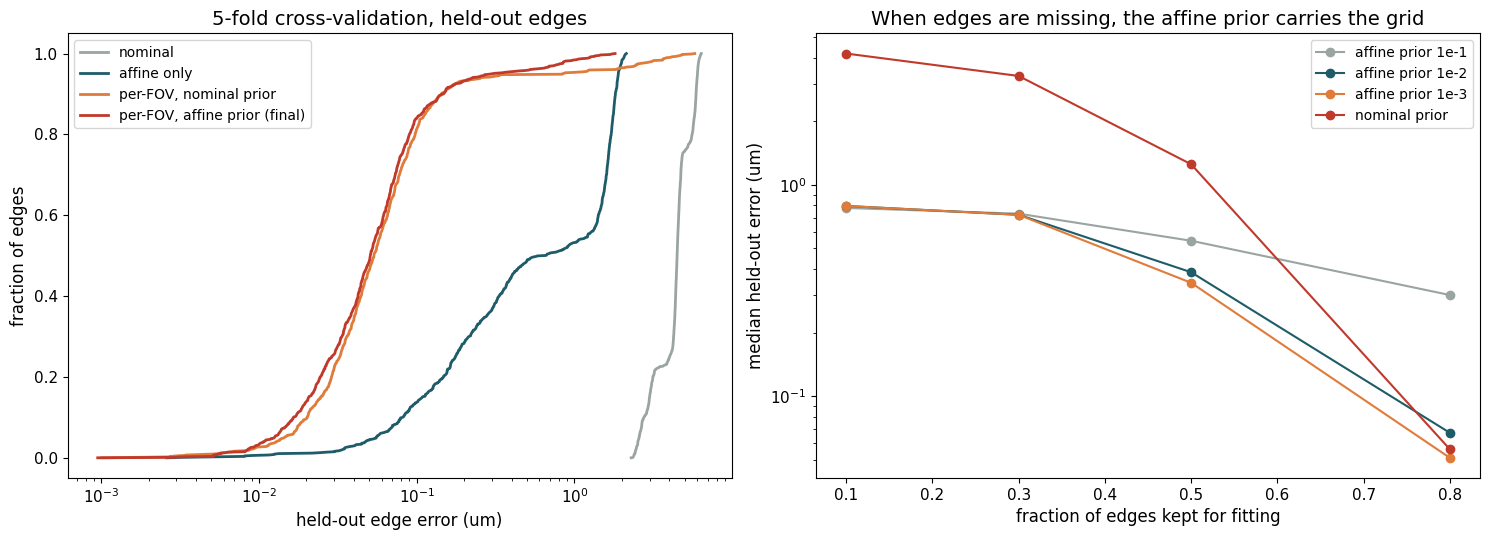

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
colors = ["#9aa5a2", "#1d5c68", "#e07b39", "#c0392b"]
for (k, v), c in zip(res.items(), colors):
    v = np.sort(v); ax[0].plot(v, np.arange(1, len(v) + 1) / len(v), color=c, lw=2, label=k)
ax[0].set_xscale("log"); ax[0].set_xlabel("held-out edge error (um)"); ax[0].set_ylabel("fraction of edges")
ax[0].set_title("5-fold cross-validation, held-out edges"); ax[0].legend()
for (m, col), c in zip(sweep.items(), colors):
    ax[1].plot(sweep.index, col, marker="o", color=c, label=m)
ax[1].set_xlabel("fraction of edges kept for fitting"); ax[1].set_ylabel("median held-out error (um)")
ax[1].set_yscale("log"); ax[1].set_title("When edges are missing, the affine prior carries the grid"); ax[1].legend()
fig.tight_layout(); save(fig, "cross_validation")

## Notes (numbers quoted by the HTML)

- Old cache: 894 edges measured from both ends, |m_ij + m_ji| max 1.8e-12 um (not independent).
- 5-fold CV, held-out edge error median / p90 (um): nominal 4.484 / 5.904; affine only 0.622 / 1.818;
  per-FOV with nominal prior 0.054 / 0.144; final (affine prior) 0.051 / 0.148.
- Fraction of edges kept for fitting 0.8 / 0.5 / 0.3 / 0.1 -> median held-out error:
  nominal prior 0.056 / 1.253 / 3.282 / 4.191; affine prior 1e-3 0.051 / 0.344 / 0.722 / 0.795;
  1e-2 0.067 / 0.386 / 0.722 / 0.795; 1e-1 0.301 / 0.544 / 0.731 / 0.778.